<a href="https://colab.research.google.com/github/rayanecardozo/TCCs/blob/main/Credit_Card_Fraud_MBA_USP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Fraude em Cartão de Crédito - Pipeline


## Etapas do Projeto




1. **Carregamento e Preparação dos Dados**
- Importação do dataset Kaggle (transações de cartões de crédito de 2013).
- Verificação de valores ausentes e estatísticas descritivas.
- Padronização das variáveis com `StandardScaler`.


2. **Análise Exploratória de Dados (EDA)**
- Distribuição de classes (fraude vs. não fraude).
- Matriz de correlação entre variáveis.
- Visualizações para melhor compreensão da base.


3. **Tratamento do Desbalanceamento**
- Aplicação do **SMOTE** exclusivamente nos dados de treino.


4. **Modelos Supervisionados**
- Random Forest.
- Support Vector Machine (SVM).
- XGBoost.
- Bagging.
- MLP (Rede Neural Multi-Camadas).


Todos os modelos são avaliados com:
- `RandomizedSearchCV` para otimização de hiperparâmetros.
- Validação cruzada estratificada.
- Métricas: **AUC-ROC, AUPRC, Precision, Recall, F1-score**.
- Matrizes de confusão para cada modelo.


5. **Modelos Não Supervisionados**
- KMeans:
- Determinação do melhor número de clusters com **Método do Cotovelo** e **Coeficiente de Silhueta**.
- Treinamento do modelo e análise dos clusters gerados.


6. **Testes de Hipótese**
- Comparação entre transações fraudulentas e não fraudulentas:
- Teste **t de Student** (para distribuições normais).
- Teste **Mann-Whitney U** (quando não normal).


7. **Interpretabilidade dos Modelos**
- Aplicação de **LIME** e **SHAP** nos melhores modelos supervisionados.
- Identificação das variáveis mais relevantes para a detecção de fraudes.


8. **Conclusão**
- Comparação entre técnicas supervisionadas e não supervisionadas.
- Discussão sobre trade-offs entre acurácia preditiva e interpretabilidade.

## Execução meio duvidosa rs

In [ ]:
# 1 - Imports e configurações necessárias
import os
import json
import time
import warnings
warnings.filterwarnings('ignore')


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, roc_curve, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans

from scipy.stats import mannwhitneyu, ttest_ind, normaltest
from scipy.stats import randint, uniform, loguniform

# try optional xgboost
try:
  from xgboost import XGBClassifier
  XGB_AVAILABLE = True
except Exception:
  XGB_AVAILABLE = False


# try optional interpret libs
try:
  import shap
  SHAP_AVAILABLE = True
except Exception:
  SHAP_AVAILABLE = False


try:
  from lime.lime_tabular import LimeTabularExplainer
  LIME_AVAILABLE = True
except Exception:
  LIME_AVAILABLE = False


# Configs
RANDOM_STATE = 42
TEST_SIZE = 0.3
N_JOBS = -1
OUTPUT_DIR = "./outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


DATA_PATH = "./creditcard.csv"
TARGET = "Class"

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from collections import Counter

# -----------------------
# Load data
# -----------------------
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
if TARGET not in df.columns:
    raise ValueError(f"Coluna alvo '{TARGET}' não encontrada. Colunas: {list(df.columns)}")

# numeric/categorical separation
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]
print(f"Num cols: {len(num_cols)} | Cat cols: {len(cat_cols)}")


# -----------------------
# Apply SMOTE
# -----------------------
if cat_cols:
    print("⚠️ Warning: SMOTE only applied to numeric features. Categoricals ignored.")
    sm = SMOTE(random_state=42)
    X_res_num, y_res = sm.fit_resample(X[num_cols], y)
    cat_res = X[cat_cols].iloc[y_res.index % len(X)].reset_index(drop=True)
    X_res = pd.concat([X_res_num, cat_res], axis=1)
else:
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X, y)

print(f"Resampled dataset shape: {X_res.shape}, class distribution: {Counter(y_res)}")

# Make "before" and "after" dataframes for easy comparison
df_before = pd.concat([X[num_cols], y.rename(TARGET)], axis=1)
df_after  = pd.concat([X_res[num_cols], y_res.rename(TARGET)], axis=1)


# -----------------------
# Target distribution BEFORE vs AFTER
# -----------------------
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.countplot(x=y)
plt.title("Target distribution (before SMOTE)")

plt.subplot(1,2,2)
sns.countplot(x=y_res)
plt.title("Target distribution (after SMOTE)")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "target_distribution_comparison.png"))
plt.close()
print("Saved target distribution comparison (before vs after).")


# -----------------------
# Correlation heatmap BEFORE vs AFTER
# -----------------------
corr_before = df_before.corr()
corr_after  = df_after.corr()

plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
sns.heatmap(corr_before, cmap='RdBu_r', center=0, annot=False)
plt.title("Correlation heatmap (before SMOTE)")

plt.subplot(1,2,2)
sns.heatmap(corr_after, cmap='RdBu_r', center=0, annot=False)
plt.title("Correlation heatmap (after SMOTE)")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "correlation_heatmap_comparison.png"))
plt.close()
print("Saved correlation heatmap comparison (before vs after).")


# -----------------------
# Numeric distributions BEFORE vs AFTER
# -----------------------
for col in num_cols:
    plt.figure(figsize=(12,6))

    # Histograms
    plt.subplot(2,2,1)
    sns.histplot(df_before[col].dropna(), bins=30, kde=True)
    plt.title(f'{col} distribution (before SMOTE)')

    plt.subplot(2,2,2)
    sns.histplot(df_after[col].dropna(), bins=30, kde=True, color="orange")
    plt.title(f'{col} distribution (after SMOTE)')

    # Boxplots
    plt.subplot(2,2,3)
    sns.boxplot(x=df_before[col].dropna(), orient='h')
    plt.title(f'{col} boxplot (before SMOTE)')

    plt.subplot(2,2,4)
    sns.boxplot(x=df_after[col].dropna(), orient='h', color="orange")
    plt.title(f'{col} boxplot (after SMOTE)')

    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, f'{col}_comparison.png')
    plt.savefig(out_path, bbox_inches='tight')
    plt.close()

print(f"Saved side-by-side comparisons for {len(num_cols)} numeric columns.")


# -----------------------
# Categorical distributions (before only)
# -----------------------
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    order = df[col].value_counts().index[:20]
    sns.countplot(data=df, x=col, order=order)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Value counts of {col} (before SMOTE)')
    plt.tight_layout()

    out_path = os.path.join(OUTPUT_DIR, f'{col}_counts.png')
    plt.savefig(out_path, bbox_inches='tight')
    plt.close()

print(f"Saved barplots for {len(cat_cols)} categorical columns (before SMOTE).")


Shape: (284807, 31)
Num cols: 30 | Cat cols: 0
Resampled dataset shape: (568630, 30), class distribution: Counter({0: 284315, 1: 284315})
Saved target distribution comparison (before vs after).
Saved correlation heatmap comparison (before vs after).
Saved side-by-side comparisons for 30 numeric columns.
Saved barplots for 0 categorical columns (before SMOTE).


In [ ]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


Train/test shapes: (199364, 30) (85443, 30)
Fraud rate train/test: 0.0017254870488152324 0.0017321489179921118

RF No SMOTE no SMOTE Results
----------------------------------------
Accuracy : 0.99952015
Precision: 0.95726496
Recall   : 0.75675676
F1-score : 0.84528302
ROC-AUC  : 0.93074552
AUPRC    : 0.82272212

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.96      0.76      0.85       148

    accuracy                           1.00     85443
   macro avg       0.98      0.88      0.92     85443
weighted avg       1.00      1.00      1.00     85443


RF with SMOTE Results
----------------------------------------
Accuracy : 0.99946163
Precision: 0.89230769
Recall   : 0.78378378
F1-score : 0.83453237
ROC-AUC  : 0.96899940
AUPRC    : 0.82813335

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
      

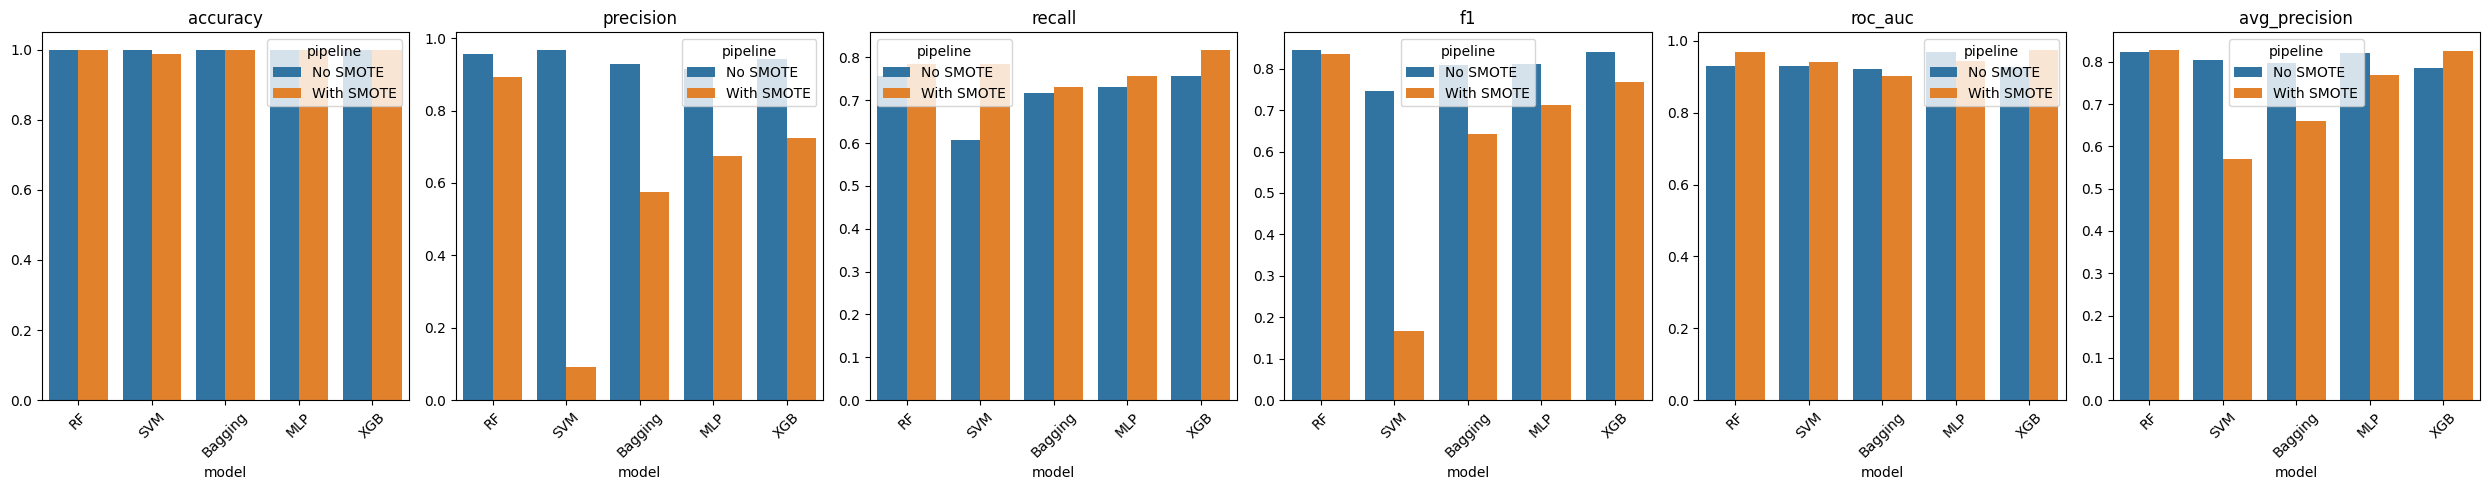

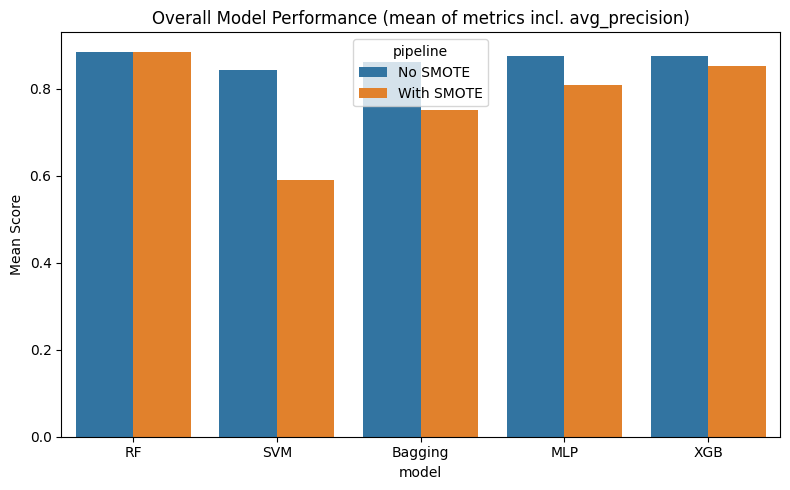

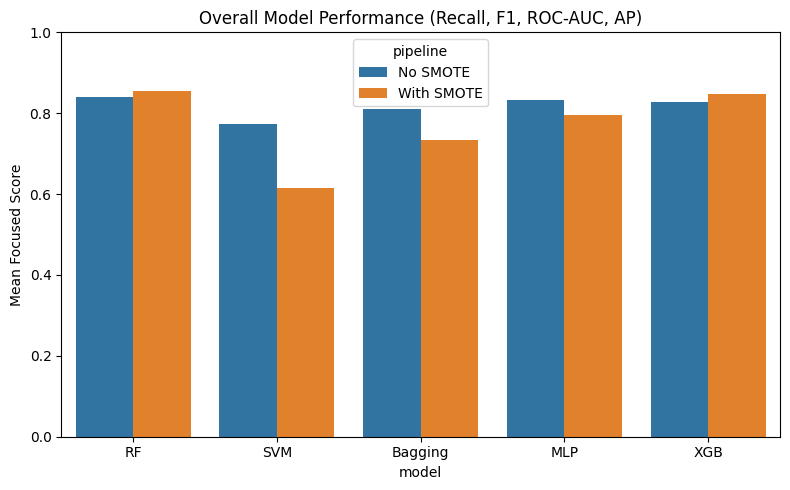

In [ ]:
# 5 - Compare Baseline Models With/Without SMOTE + Average Precision
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ------------------------
# Train/Test Split
# ------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
print("Train/test shapes:", X_train.shape, X_test.shape)
print("Fraud rate train/test:", y_train.mean(), y_test.mean())

# ------------------------
# Preprocessor
# ------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# ------------------------
# Models
# ------------------------
model_defs = {
    "RF": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "Bagging": BaggingClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS),
    "MLP": MLPClassifier(random_state=RANDOM_STATE, early_stopping=True, max_iter=200)
}
if XGB_AVAILABLE:
    model_defs["XGB"] = XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        use_label_encoder=False,
        n_jobs=N_JOBS
    )

# ------------------------
# Evaluation function
# ------------------------
def evaluate_model(name, model, use_smote=False):
    if use_smote:
        pipe = ImbPipeline([
            ("pre", preprocessor),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            ("clf", model)
        ])
        name = name + ' with SMOTE'
    else:
        pipe = Pipeline([
            ("pre", preprocessor),
            ("clf", model)
        ])
        name = name + ' no SMOTE'

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred, output_dict=True)
    acc = report["accuracy"]
    prec = report["1"]["precision"]
    rec = report["1"]["recall"]
    f1 = report["1"]["f1-score"]
    roc = roc_auc_score(y_test, y_prob)
    auprc = average_precision_score(y_test, y_prob)

    print(f"\n{name} Results")
    print("-"*40)
    print(f"Accuracy : {acc:.8f}")
    print(f"Precision: {prec:.8f}")
    print(f"Recall   : {rec:.8f}")
    print(f"F1-score : {f1:.8f}")
    print(f"ROC-AUC  : {roc:.8f}")
    print(f"AUPRC    : {auprc:.8f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return {
        "model": name,
        "accuracy": report["accuracy"],
        "precision": report["1"]["precision"],
        "recall": report["1"]["recall"],
        "f1": report["1"]["f1-score"],
        "roc_auc": roc,
        "avg_precision": auprc
    }

# ------------------------
# Run all models with/without SMOTE
# ------------------------
results = []
for name, model in model_defs.items():
    # No SMOTE
    res_no = evaluate_model(name+" No SMOTE", model, use_smote=False)
    res_no["model"] = name
    res_no["pipeline"] = "No SMOTE"
    results.append(res_no)

    # With SMOTE
    res_smote = evaluate_model(name, model, use_smote=True)
    res_smote["model"] = name
    res_smote["pipeline"] = "With SMOTE"
    results.append(res_smote)

results_df = pd.DataFrame(results)
print(results_df)

# save baseline results
pd.DataFrame(results_df).to_csv(os.path.join(OUTPUT_DIR,'results_baseline.csv'), index=False)

# ------------------------
# Plot side-by-side
# ------------------------
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc", "avg_precision"]

fig, axes = plt.subplots(1, len(metrics), figsize=(25, 5), sharey=False)
for i, metric in enumerate(metrics):
    sns.barplot(
        data=results_df,
        x="model", y=metric, hue="pipeline", ax=axes[i]
    )
    axes[i].set_title(metric)
    axes[i].set_ylabel("")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "baseline_models_comparison.png"))
plt.show()

# ------------------------
# Combined plot (mean score across all metrics)
# ------------------------
results_df["mean_score"] = results_df[metrics].mean(axis=1)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=results_df,
    x="model", y="mean_score", hue="pipeline"
)
plt.title("Overall Model Performance (mean of metrics incl. avg_precision)")
plt.ylabel("Mean Score")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "baseline_models_combined.png"))
plt.show()

# ------------------------
# Combined plot (focus on imbalance metrics)
# ------------------------
focus_metrics = ["recall", "f1", "roc_auc", "avg_precision"]
results_df["mean_focus_score"] = results_df[focus_metrics].mean(axis=1)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=results_df,
    x="model", y="mean_focus_score", hue="pipeline"
)
plt.title("Overall Model Performance (Recall, F1, ROC-AUC, AP)")
plt.ylabel("Mean Focused Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "baseline_models_combined_focus.png"))
plt.show()



In [ ]:
from sklearn.utils import resample
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform


def plot_and_save_curves(y_true, y_score, name):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    plt.figure(); plt.plot(fpr,tpr); plt.plot([0,1],[0,1],'--'); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title(name+' ROC'); plt.grid(True)
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, f'{name}_roc.png')); plt.close()

    prec, rec, _ = precision_recall_curve(y_true, y_score)
    plt.figure(); plt.plot(rec, prec); plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title(name+' PR'); plt.grid(True)
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, f'{name}_pr.png')); plt.close()



def plot_and_save_confusion(y_true, y_score, name, thr=0.5):
    y_pred = (y_score >= thr).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    plt.figure(); plt.imshow(cm, interpolation='nearest'); plt.colorbar(); plt.title(name+' Confusion'); plt.xticks([0,1],['NoFraud','Fraud']); plt.yticks([0,1],['NoFraud','Fraud'])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i,j], ha='center', va='center')
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, f'{name}_confusion.png')); plt.close()

# -----------------------
# Pipelines
# -----------------------
# pipe_no_smote = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('model', RandomForestClassifier(
#         n_estimators=200,
#         random_state=RANDOM_STATE,
#         n_jobs=-1
#     ))
# ])

# pipe_smote = ImbPipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('smote', SMOTE(random_state=RANDOM_STATE)),
#     ('model', RandomForestClassifier(
#         n_estimators=200,
#         random_state=RANDOM_STATE,
#         n_jobs=-1
#     ))
# ])


# ------------------------
# RandomizedSearch spaces
# ------------------------

# Random Forest
rf_search_no_smote = RandomizedSearchCV(
    estimator=Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS))]),
    param_distributions={
        'clf__n_estimators': randint(200, 400),
        'clf__max_depth': randint(4, 20),
        'clf__min_samples_split': randint(2, 10),
        'clf__min_samples_leaf': randint(1, 5),
        'clf__max_features': ['sqrt', 'log2']
    },
    n_iter=12,
    scoring='average_precision',
    cv=3,
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True
)

rf_search_smote = RandomizedSearchCV(
    estimator=ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS))]),
    param_distributions={
        'clf__n_estimators': randint(200, 400),
        'clf__max_depth': randint(4, 20),
        'clf__min_samples_split': randint(2, 10),
        'clf__min_samples_leaf': randint(1, 5),
        'clf__max_features': ['sqrt', 'log2']
    },
    n_iter=12,
    scoring='average_precision',
    cv=3,
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True
)


# Bagging
bag_search_no_smote = RandomizedSearchCV(
    estimator=Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('clf', BaggingClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS))]),
    param_distributions={
        'clf__n_estimators': randint(50, 200),
        'clf__max_samples': uniform(0.5, 0.5),
        'clf__max_features': uniform(0.5, 0.5)
    },
    n_iter=10,
    scoring='average_precision',
    cv=3,
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True
)

bag_search_smote = RandomizedSearchCV(
    estimator=ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf', BaggingClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS))]),
    param_distributions={
        'clf__n_estimators': randint(50, 200),
        'clf__max_samples': uniform(0.5, 0.5),
        'clf__max_features': uniform(0.5, 0.5)
    },
    n_iter=10,
    scoring='average_precision',
    cv=3,
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True
)

# MLP
mlp_search_no_smote = RandomizedSearchCV(
    estimator=Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('clf', MLPClassifier(random_state=RANDOM_STATE, early_stopping=True, max_iter=200))]),
    param_distributions={
        'clf__hidden_layer_sizes': [(64, 32), (128, 64), (128, 64, 32)],
        'clf__alpha': loguniform(1e-6, 1e-2),
        'clf__learning_rate_init': loguniform(1e-4, 1e-2),
        'clf__activation': ['relu', 'tanh']
    },
    n_iter=10,
    scoring='average_precision',
    cv=3,
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True
)

mlp_search_smote = RandomizedSearchCV(
    estimator=ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf', MLPClassifier(random_state=RANDOM_STATE, early_stopping=True, max_iter=200))]),
    param_distributions={
        'clf__hidden_layer_sizes': [(64, 32), (128, 64), (128, 64, 32)],
        'clf__alpha': loguniform(1e-6, 1e-2),
        'clf__learning_rate_init': loguniform(1e-4, 1e-2),
        'clf__activation': ['relu', 'tanh']
    },
    n_iter=10,
    scoring='average_precision',
    cv=3,
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True
)


# SVM (small subsample!)
svm_search_no_smote = RandomizedSearchCV(
    estimator=Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('clf', SVC(probability=True, random_state=RANDOM_STATE))]),
    param_distributions={
        'clf__C': loguniform(1e-2, 1e3),
        'clf__gamma': loguniform(1e-4, 1e0),
        'clf__kernel': ['rbf', 'poly'],
        'clf__degree': randint(2, 5)
    },
    n_iter=5,   # very small, keep runtime reasonable
    scoring='average_precision',
    cv=2,       # lighter CV for SVM
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True
)

svm_search_smote = RandomizedSearchCV(
    estimator=ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf', SVC(probability=True, random_state=RANDOM_STATE))]),
    param_distributions={
        'clf__C': loguniform(1e-2, 1e3),
        'clf__gamma': loguniform(1e-4, 1e0),
        'clf__kernel': ['rbf', 'poly'],
        'clf__degree': randint(2, 5)
    },
    n_iter=5,   # very small, keep runtime reasonable
    scoring='average_precision',
    cv=2,       # lighter CV for SVM
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True
)


# XGB (if available)
if XGB_AVAILABLE:
    xgb_search_no_smote = RandomizedSearchCV(
        estimator=Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('clf', XGBClassifier(
                random_state=RANDOM_STATE,
                use_label_encoder=False,
                eval_metric='logloss',
                n_jobs=N_JOBS
            )
        )]),
        param_distributions={
            'clf__n_estimators': randint(200, 400),
            'clf__max_depth': randint(3, 8),
            'clf__learning_rate': loguniform(1e-3, 3e-1),
            'clf__subsample': uniform(0.6, 0.4),
            'clf__colsample_bytree': uniform(0.6, 0.4),
            'clf__min_child_weight': randint(1, 6)
        },
        n_iter=12,
        scoring='average_precision',
        cv=3,
        n_jobs=N_JOBS,
        random_state=RANDOM_STATE,
        verbose=1,
        refit=True
    )


    xgb_search_smote = RandomizedSearchCV(
        estimator=ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf', XGBClassifier(
                random_state=RANDOM_STATE,
                use_label_encoder=False,
                eval_metric='logloss',
                n_jobs=N_JOBS
            )
        )]),
        param_distributions={
            'clf__n_estimators': randint(200, 400),
            'clf__max_depth': randint(3, 8),
            'clf__learning_rate': loguniform(1e-3, 3e-1),
            'clf__subsample': uniform(0.6, 0.4),
            'clf__colsample_bytree': uniform(0.6, 0.4),
            'clf__min_child_weight': randint(1, 6)
        },
        n_iter=12,
        scoring='average_precision',
        cv=3,
        n_jobs=N_JOBS,
        random_state=RANDOM_STATE,
        verbose=1,
        refit=True
    )

# ------------------------
# Run searches
# ------------------------
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import average_precision_score

# dictionary to hold mean CV AUPRC
auprc_folds = {}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE) # same folds for all models

searches_no_smote = {'RF': rf_search_no_smote,
                     'Bagging': bag_search_no_smote,
                     'MLP': mlp_search_no_smote,
                     'SVM': svm_search_no_smote}
if XGB_AVAILABLE:
    searches_no_smote['XGB'] = xgb_search_no_smote

searches_smote = {'RF': rf_search_smote,
                     'Bagging': bag_search_smote,
                     'MLP': mlp_search_smote,
                     'SVM': svm_search_smote}
if XGB_AVAILABLE:
    searches_smote['XGB'] = xgb_search_smote

def to_proba(model, X_):
  try:
    return model.predict_proba(X_)[:,1]
  except Exception:
    if hasattr(model, 'decision_function'):
        s = model.decision_function(X_)
        return (s - s.min())/(s.max()-s.min()+1e-12)
  else:
        return model.predict(X_)


def evaluate_search(name, search):
    search.fit(X_train, y_train)

    # Get best estimator
    best = search.best_estimator_
    print(f"Best params for {name}: {search.best_params_}")

    # --- 3-fold CV evaluation with per-fold AUPRC ---
    fold_auprcs = []
    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):
        # use .iloc for row-based selection
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # clone model to avoid reusing the same fitted instance
        from sklearn.base import clone
        model_cv = clone(best)
        model_cv.fit(X_tr, y_tr)

        y_val_proba = to_proba(model_cv, X_val)
        fold_auprc = average_precision_score(y_val, y_val_proba)
        fold_auprcs.append(fold_auprc)

        print(f"{name} | Fold {fold_idx} AUPRC: {fold_auprc:.8f}")

    # Evaluate
    y_tr_proba = to_proba(best, X_train)
    y_te_proba = to_proba(best, X_test)

    metrics = {
        'model': name + '_tuned',
        'accuracy_train': accuracy_score(y_train, (y_tr_proba >= 0.5).astype(int)),
        'accuracy_test': accuracy_score(y_test, (y_te_proba >= 0.5).astype(int)),
        'precision_train': precision_score(y_train, (y_tr_proba >= 0.5).astype(int)),
        'precision_test': precision_score(y_test, (y_te_proba >= 0.5).astype(int)),
        'recall_train': recall_score(y_train, (y_tr_proba >= 0.5).astype(int)),
        'recall_test': recall_score(y_test, (y_te_proba >= 0.5).astype(int)),
        'f1_train': f1_score(y_train, (y_tr_proba >= 0.5).astype(int)),
        'f1_test': f1_score(y_test, (y_te_proba >= 0.5).astype(int)),
        'roc_auc_train': roc_auc_score(y_train, y_tr_proba),
        'roc_auc_test': roc_auc_score(y_test, y_te_proba),
        'auprc_train': average_precision_score(y_train, y_tr_proba),
        'auprc_test': average_precision_score(y_test, y_te_proba),
        'best_params': search.best_params_
    }

    # Save plots
    plot_and_save_curves(y_test, y_te_proba, name + '_tuned')
    plot_and_save_confusion(y_test, y_te_proba, name + '_tuned')

    return metrics, fold_auprcs


model_names = ["RF", "SVM", "XGB", "MLP", "Bagging"]
auprc_folds = {}
metrics_tuned = []
for name in model_names:
    print(f"\n>>> Running RandomizedSearch for {name} ...")

    search_no_smote = searches_no_smote[name]
    metrics, auprc_folds[name + "_no_smote"] = evaluate_search(name + "_no_smote", search_no_smote)  # list of 3 values
    metrics_tuned.append(metrics)

    search_smote = searches_smote[name]
    metrics, auprc_folds[name + "_smote"] = evaluate_search(name + "_smote", search_smote)  # list of 3 values
    metrics_tuned.append(metrics)

# Save metrics
pd.DataFrame(metrics_tuned).to_csv(
    os.path.join(OUTPUT_DIR, 'results_tuned.csv'), index=False
)



>>> Running RandomizedSearch for RF ...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params for RF_no_smote: {'clf__max_depth': 17, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 3, 'clf__min_samples_split': 7, 'clf__n_estimators': 250}
RF_no_smote | Fold 1 AUPRC: 0.86718559
RF_no_smote | Fold 2 AUPRC: 0.83213806
RF_no_smote | Fold 3 AUPRC: 0.83839957
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params for RF_smote: {'clf__max_depth': 19, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 9, 'clf__n_estimators': 214}
RF_smote | Fold 1 AUPRC: 0.85970421
RF_smote | Fold 2 AUPRC: 0.84592107
RF_smote | Fold 3 AUPRC: 0.82914952

>>> Running RandomizedSearch for SVM ...
Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best params for SVM_no_smote: {'clf__C': np.float64(492.90536482416695), 'clf__degree': 3, 'clf__gamma': np.float64(0.000533703276260396), 'clf__kernel': 'rbf'}
SVM_no_smote | Fold 1 AU

In [ ]:
# 6 - KMeans (Elbow + Silhouette)

# Prepare numeric scaled matrix
X_all_num = df[num_cols].fillna(df[num_cols].median())
scaler_all = StandardScaler(); X_all_scaled = scaler_all.fit_transform(X_all_num)

# sample for speed
SAMPLE_FOR_KMEANS = 20000
if X_all_scaled.shape[0] > SAMPLE_FOR_KMEANS:
    idx = np.random.RandomState(RANDOM_STATE).choice(X_all_scaled.shape[0], SAMPLE_FOR_KMEANS, replace=False)
    X_km_sample = X_all_scaled[idx]
else:
    X_km_sample = X_all_scaled

Ks = list(range(2,11))
wcss = []
sil_scores = []
from sklearn.metrics import silhouette_score
for k in Ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_km_sample)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_km_sample, km.labels_))

plt.figure(); plt.plot(Ks, wcss, marker='o'); plt.xlabel('k'); plt.ylabel('WCSS'); plt.title('Elbow'); plt.grid(True)
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,'elbow_kmeans.png')); plt.close()

plt.figure(); plt.plot(Ks, sil_scores, marker='o'); plt.xlabel('k'); plt.ylabel('Silhouette'); plt.title('Silhouette'); plt.grid(True)
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,'silhouette_kmeans.png')); plt.close()

best_k = Ks[int(np.argmax(sil_scores))]
print('Best k (silhouette):', best_k)

kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
kmeans_final.fit(X_all_scaled)
df_clusters = df.copy()
df_clusters['cluster'] = kmeans_final.labels_
df_clusters.to_csv(os.path.join(OUTPUT_DIR,'df_with_clusters.csv'), index=False)


# quick crosstab cluster x fraud
ct = pd.crosstab(df_clusters['cluster'], df_clusters[TARGET], normalize='index')
ct.to_csv(os.path.join(OUTPUT_DIR,'cluster_vs_fraud.csv'))

Best k (silhouette): 9


In [ ]:
# 7 - ANOVA (one-way) entre RF, SVM, XGB, MLP, Bagging (RandomizedSearchCV) e KMeans (k=best_k)
import re, numpy as np, pandas as pd, os
from scipy.stats import f_oneway
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import average_precision_score

# auprc_folds deve estar preenchido com melhor resultado (average_precision_score) para cada modelo

# Garante que temos pelo menos 2 modelos supervisionados
# assert sum([1 for k in auprc_folds if k in model_names]) >= 2, "Preciso de pelo menos 2 modelos dos RandomizedSearchCV."

# --- 7.2 Inclui KMeans como 'classificador' usando best_k da #6 (sem refazer busca de k)
assert 'best_k' in globals() and best_k is not None, "best_k não encontrado. Rode a célula #6 antes."
auprc_folds["KMeans"] = []
for tr, te in cv.split(X, y):
    Xtr, Xte = X.iloc[tr], X.iloc[te]
    ytr, yte = y.iloc[tr], y.iloc[te]

    scaler = StandardScaler().fit(Xtr[num_cols])
    Xtr_s = scaler.transform(Xtr[num_cols])
    Xte_s = scaler.transform(Xte[num_cols])

    km = KMeans(n_clusters=int(best_k), random_state=42, n_init=10).fit(Xtr_s)
    cl_tr = km.labels_
    # mapeia cluster->classe pela maioria no TREINO (evita vazamento)
    mapping = {c: ytr.iloc[np.where(cl_tr==c)[0]].mode()[0] for c in np.unique(cl_tr)}
    yhat_te = np.array([mapping[c] for c in km.predict(Xte_s)])  # rótulo 0/1
    auprc_folds["KMeans"].append(average_precision_score(yte, yhat_te))

# --- 7.3 ANOVA one-way sobre AUPRC por fold
anova = f_oneway(*auprc_folds.values())
print("ANOVA one-way (AUPRC por fold): F=%.8f  p=%.8g" % (anova.statistic, anova.pvalue))

df_auprc_folds = pd.DataFrame(auprc_folds)
display(df_auprc_folds)

# (opcional) salvar
if 'OUTPUT_DIR' in globals():
    df_auprc_folds.to_csv(os.path.join(OUTPUT_DIR, "auprc_por_fold_RS_e_kmeans.csv"), index=False)


ANOVA one-way (AUPRC por fold): F=26.40706897  p=5.6713548e-10


,RF_no_smote,RF_smote,SVM_no_smote,SVM_smote,XGB_no_smote,XGB_smote,MLP_no_smote,MLP_smote,Bagging_no_smote,Bagging_smote,KMeans
0,0.867186,0.859704,0.852496,0.693478,0.865507,0.860314,0.834473,0.840640,0.860839,0.851623,0.280155
1,0.832138,0.845921,0.806596,0.681776,0.870313,0.863085,0.867179,0.781233,0.827602,0.838302,0.001727
2,0.838400,0.829150,0.825622,0.645212,0.838404,0.828617,0.839370,0.804624,0.830134,0.836378,0.390696


In [ ]:
from sklearn.metrics import accuracy_score

def evaluate_best_models(searches, name, pipeline):
    search = searches[name]
    best = search.best_estimator_
    # Evaluate
    y_tr_proba = to_proba(best, X_train)
    y_te_proba = to_proba(best, X_test)

    metrics = {
        'model': name + '_' + pipeline + '_tuned',
        'accuracy_train': accuracy_score(y_train, (y_tr_proba >= 0.5).astype(int)),
        'accuracy_test': accuracy_score(y_test, (y_te_proba >= 0.5).astype(int)),
        'precision_train': precision_score(y_train, (y_tr_proba >= 0.5).astype(int)),
        'precision_test': precision_score(y_test, (y_te_proba >= 0.5).astype(int)),
        'recall_train': recall_score(y_train, (y_tr_proba >= 0.5).astype(int)),
        'recall_test': recall_score(y_test, (y_te_proba >= 0.5).astype(int)),
        'f1_train': f1_score(y_train, (y_tr_proba >= 0.5).astype(int)),
        'f1_test': f1_score(y_test, (y_te_proba >= 0.5).astype(int)),
        'roc_auc_train': roc_auc_score(y_train, y_tr_proba),
        'roc_auc_test': roc_auc_score(y_test, y_te_proba),
        'auprc_train': average_precision_score(y_train, y_tr_proba),
        'auprc_test': average_precision_score(y_test, y_te_proba),
        'best_params': search.best_params_
    }

    return metrics

metrics_tuned = []
for name in model_defs:
    metrics_no_smote = evaluate_best_models(searches_no_smote, name, 'no_smote')
    metrics_smote = evaluate_best_models(searches_smote, name, 'smote')
    metrics_tuned.append(metrics_no_smote)
    metrics_tuned.append(metrics_smote)

# Save metrics
pd.DataFrame(metrics_tuned).to_csv(
    os.path.join(OUTPUT_DIR, 'results_tuned.csv'), index=False
)

RF
SVM
Bagging
MLP
XGB
Top model for interpretation: XGB_no_smote_tuned


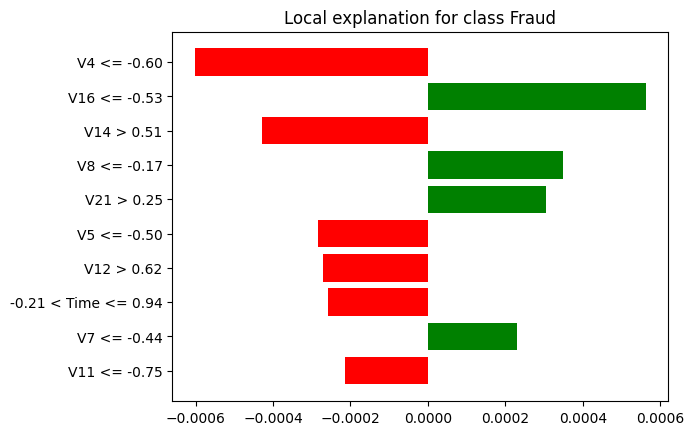

In [ ]:
# 8 - Interpretability (SHAP & LIME)
# escolha o modelo mais bem ajustado por auprc_test se disponível
try:
    tuned_df = pd.read_csv(os.path.join(OUTPUT_DIR,'results_tuned.csv'))
    top_model_name = tuned_df.sort_values(by='auprc_test', ascending=False).iloc[0]['model']
except Exception:
    top_model_name = None

best_models = {}
for name in model_defs:
    name_no_smote = name + "_no_smote_tuned"
    name_smote = name + "_smote_tuned"
    found_no_smote = []
    for d in metrics_tuned:
        if name_no_smote in d.values():
            found_no_smote = d
            break

    found_smote = []
    for d in metrics_tuned:
        if name_smote in d.values():
            found_smote = d
            break

    print(name)
    best_models[name] = searches_no_smote[name].best_estimator_ if (found_no_smote["auprc_test"] > found_smote["auprc_test"]) else searches_smote[name].best_estimator_

# mapping names to best_models (searches keys)
obj_map = {}
for k,v in best_models.items():
    obj_map[k] = v
for k,v in list(best_models.items()):
    obj_map[k] = v

# fallback: choose one of baseline
if top_model_name is None and len(best_models)>0:
    top_model_name = list(best_models.keys())[0]

print('Top model for interpretation:', top_model_name)
names = top_model_name.split("_")
name = names[0]

if top_model_name and SHAP_AVAILABLE:
    model_obj = best_models[name]
    if model_obj is not None:
        # prepare transformed test set (use pre from pipeline)
        pre = model_obj.named_steps['preprocessor'] if 'preprocessor' in model_obj.named_steps else model_obj.named_steps.get('preprocessor')
        # Transform X_test
        X_test_proc = pre.transform(X_test)
        # SHAP
        try:
            clf = model_obj.named_steps['clf']
            if hasattr(clf,'feature_importances_'):
                explainer = shap.TreeExplainer(clf)
                shap_values = explainer(X_test_proc[:500])
                shap.summary_plot(shap_values, X_test_proc[:500], show=False)
                plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,f'shap_summary_{top_model_name}.png')); plt.close()
        except Exception as e:
            print('SHAP failed:', e)
else:
    print('SHAP not available or no top model found; skipping SHAP')

if LIME_AVAILABLE and top_model_name:
    try:
        model_obj = best_models[name]
        if model_obj is not None:
            pre = model_obj.named_steps['preprocessor']
            X_train_proc = pre.transform(X_train)
            feature_names = num_cols + cat_cols
            explainer = LimeTabularExplainer(training_data=np.array(X_train_proc), feature_names=feature_names, class_names=['NoFraud','Fraud'], mode='classification')
            # explain one instance
            x0 = pre.transform(X_test.iloc[[0]])
            exp = explainer.explain_instance(x0[0], model_obj.named_steps['clf'].predict_proba, num_features=10)
            fig = exp.as_pyplot_figure(); fig.savefig(os.path.join(OUTPUT_DIR,f'lime_explain_{top_model_name}.png'), bbox_inches='tight', pad_inches=0.2)
    except Exception as e:
        print('LIME failed:', e)
else:
    print('LIME not available or no top model; skipping LIME')